In [1]:
import numpy as np
import strawberryfields as sf
import tensorflow as tf

# ── Parameter sistem (Bose-Hubbard dari Section 5.1) ─────────────────────
J      = 1.0    # hopping integral
U      = 1.5    # on-site interaction
cutoff = 8      # Fock space truncation

# ── Ground state eksak via diagonalisasi klasik (sebagai benchmark) ───────
# Basis: |0,2⟩, |1,1⟩, |2,0⟩ (subspace 2 foton)
# Matrix Bose-Hubbard dalam subspace ini:
# H|0,2⟩ = U/2*(0+4-0-2)|0,2⟩ + J*√2|1,1⟩     = U|0,2⟩ + J√2|1,1⟩
# H|1,1⟩ = J*√2|0,2⟩ + 0|1,1⟩ + J*√2|2,0⟩     = J√2(|0,2⟩+|2,0⟩)
# H|2,0⟩ = J*√2|1,1⟩ + U|2,0⟩

H_matrix = np.array([
    [U,       J*np.sqrt(2), 0          ],   # ket |0,2⟩
    [J*np.sqrt(2), 0,       J*np.sqrt(2)],   # ket |1,1⟩
    [0,       J*np.sqrt(2), U          ]    # ket |2,0⟩
])

eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
E0_exact = eigenvalues[0]
psi0_exact = eigenvectors[:, 0]

print(f"Eigenvalues Bose-Hubbard (subspace 2 foton):")
for i, e in enumerate(eigenvalues):
    print(f"  E_{i} = {e:.6f}")
print(f"\nGround state energy (eksak): E₀ = {E0_exact:.6f}")
print(f"Ground state |ψ₀⟩ ≈ {np.round(psi0_exact, 4)}")

/mgpfs/home/mkhairiansyah/.conda/envs/quantum-md/lib/python3.10/site-packages/strawberryfields/apps/data/sample.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1776328385.433028 3533555 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776328385.439641 3533555 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776328387.491445 3533555 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX

Eigenvalues Bose-Hubbard (subspace 2 foton):
  E_0 = -1.386001
  E_1 = 1.500000
  E_2 = 2.886001

Ground state energy (eksak): E₀ = -1.386001
Ground state |ψ₀⟩ ≈ [-0.4028  0.8219 -0.4028]


In [2]:
# ── Fungsi expectation value ⟨H⟩ dari statevector ────────────────────────
def bose_hubbard_energy(statevec, J, U, cutoff):
    """
    Hitung ⟨ψ|H_BH|ψ⟩ secara analitik dari statevector dalam Fock basis.
    
    H = J(â†₁â₂ + â†₂â₁) + U/2(n̂₁²-n̂₁ + n̂₂²-n̂₂)
    
    Ini adalah cost function VQE yang sebenarnya — bukan fidelity!
    """
    sv = statevec
    energy = 0.0

    for i in range(cutoff):
        for j in range(cutoff):
            prob = np.abs(sv[i, j])**2  # |c_{ij}|²

            # On-site term: U/2 * (i²-i + j²-j)
            energy += prob * (U / 2) * (i**2 - i + j**2 - j)

            # Hopping term: J * Re(c*_{ij} * √(i*(j+1)) * c_{i-1,j+1})
            if i > 0 and j < cutoff - 1:
                energy += J * np.real(
                    np.conj(sv[i, j]) * np.sqrt(i * (j + 1)) * sv[i-1, j+1]
                )
            if i < cutoff - 1 and j > 0:
                energy += J * np.real(
                    np.conj(sv[i, j]) * np.sqrt((i+1) * j) * sv[i+1, j-1]
                )
    return np.real(energy)

In [3]:
# ── Ansatz CV untuk VQE Qumode ─────────────────────────────────────────────
# Struktur ansatz: BSgate (entanglement) + Dgate (displacement) per mode
# Semua parameter menjadi tf.Variable yang bisa dioptimasi
#
# Justifikasi pemilihan ansatz:
# - BSgate bisa menciptakan superposisi antar mode (mirip CNOT di qubit)
# - Dgate men-displace state dalam phase space
# - Kombinasi keduanya dapat merepresentasikan berbagai state 2-mode
#
# Ini berbeda dari paper yang hanya mengoptimasi 1 gate untuk 1 tujuan foton

tf.random.set_seed(42)

# Parameter ansatz: 1 BSgate + 2 Dgate (per mode)
tf_theta = tf.Variable(tf.random.normal(shape=[], stddev=0.1))  # BSgate angle
tf_phi   = tf.Variable(tf.random.normal(shape=[], stddev=0.1))  # BSgate phase
tf_r0    = tf.Variable(tf.random.normal(shape=[], stddev=0.1))  # Dgate mode 0
tf_phi0  = tf.Variable(tf.random.normal(shape=[], stddev=0.1))  # Dgate mode 0 phase
tf_r1    = tf.Variable(tf.random.normal(shape=[], stddev=0.1))  # Dgate mode 1
tf_phi1  = tf.Variable(tf.random.normal(shape=[], stddev=0.1))  # Dgate mode 1 phase

trainable_params = [tf_theta, tf_phi, tf_r0, tf_phi0, tf_r1, tf_phi1]

# Circuit
eng     = sf.Engine(backend="tf", backend_options={"cutoff_dim": cutoff})
circuit = sf.Program(2)

# Deklarasi parameter simbolik
th, ph, r0, ph0, r1, ph1 = circuit.params("theta","phi","r0","phi0","r1","phi1")

with circuit.context as q:
    # Inisialisasi vakum |0,0⟩ (default SF)
    sf.ops.Dgate(r0, ph0)          | q[0]  # displace mode 0
    sf.ops.Dgate(r1, ph1)          | q[1]  # displace mode 1
    sf.ops.BSgate(th, ph)          | (q[0], q[1])  # entangle dua mode

E0000 00:00:1776328422.459510 3533555 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# ── Loop VQE yang BENAR ────────────────────────────────────────────────────
# Cost function = ⟨ψ(θ)|H_BH|ψ(θ)⟩
# Bukan fidelity, bukan probabilitas Fock — tapi energi Hamiltonian

opt          = tf.keras.optimizers.Adam(learning_rate=0.05)
steps        = 200
energy_history = []

print(f"Ground state energy eksak:  E₀ = {E0_exact:.6f}")
print(f"Memulai VQE Qumode dengan Hamiltonian Bose-Hubbard...\n")

for step in range(steps):
    if eng.run_progs:
        eng.reset()

    with tf.GradientTape() as tape:
        results = eng.run(circuit, args={
            "theta": tf_theta, "phi": tf_phi,
            "r0": tf_r0, "phi0": tf_phi0,
            "r1": tf_r1, "phi1": tf_phi1
        })

        # Ambil statevector dari output circuit
        sv = results.state.ket().numpy()  # shape: (cutoff, cutoff)

        # ← INI PERBEDAAN UTAMA DARI PAPER
        # Cost function = expectation value Hamiltonian, BUKAN fidelity
        E_theta = bose_hubbard_energy(sv, J, U, cutoff)
        E_theta_tf = tf.constant(E_theta, dtype=tf.float32)

        # Minimisasi ⟨H⟩ → cari ground state
        loss = E_theta_tf

    gradients = tape.gradient(loss, trainable_params)

    # Filter None gradients (jika ada parameter yang tidak terpakai)
    grads_and_vars = [
        (g, v) for g, v in zip(gradients, trainable_params) if g is not None
    ]
    opt.apply_gradients(grads_and_vars)

    energy_history.append(float(E_theta))

    if step % 40 == 0:
        print(f"Step {step:3d}: E(θ) = {float(E_theta):.6f}  "
              f"(gap ke E₀ = {float(E_theta) - E0_exact:.6f})")

print(f"\nHasil VQE Qumode:")
print(f"  E(θ_final) = {energy_history[-1]:.6f}")
print(f"  E₀ eksak   = {E0_exact:.6f}")
print(f"  Error      = {abs(energy_history[-1] - E0_exact):.6f}")

Ground state energy eksak:  E₀ = -1.386001
Memulai VQE Qumode dengan Hamiltonian Bose-Hubbard...



ValueError: not enough values to unpack (expected 2, got 0)

/tmp/ipykernel_3533555/3874943313.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


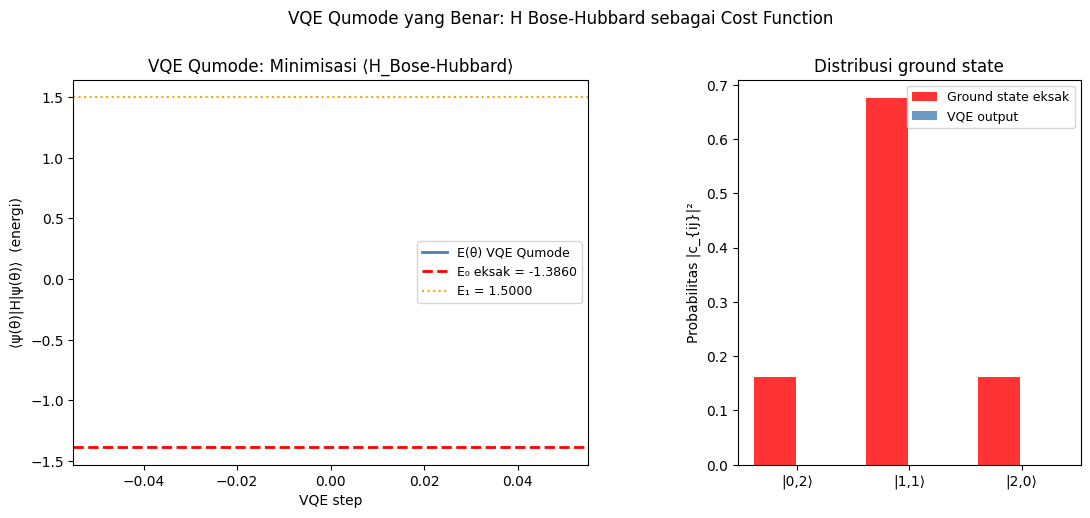

Fidelity |⟨ψ_VQE|ψ₀_eksak⟩|² = 0.0000


In [5]:
# ── Visualisasi & Perbandingan ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.35)

# Plot konvergensi energi
ax1 = fig.add_subplot(gs[0])
ax1.plot(energy_history, lw=2, color='steelblue', label='E(θ) VQE Qumode')
ax1.axhline(E0_exact, color='red', ls='--', lw=2,
            label=f'E₀ eksak = {E0_exact:.4f}')
ax1.axhline(eigenvalues[1], color='orange', ls=':', lw=1.5,
            label=f'E₁ = {eigenvalues[1]:.4f}')
ax1.set_xlabel('VQE step')
ax1.set_ylabel('⟨ψ(θ)|H|ψ(θ)⟩  (energi)')
ax1.set_title('VQE Qumode: Minimisasi ⟨H_Bose-Hubbard⟩')
ax1.legend(fontsize=9)

# Plot distribusi probabilitas ground state
ax2 = fig.add_subplot(gs[1])
labels   = ['|0,2⟩', '|1,1⟩', '|2,0⟩']
p_vqe    = [abs(sv[0,2])**2, abs(sv[1,1])**2, abs(sv[2,0])**2]
p_exact  = [abs(psi0_exact[0])**2, abs(psi0_exact[1])**2, abs(psi0_exact[2])**2]
x        = np.arange(3)

ax2.bar(x - 0.2, p_exact, 0.38, label='Ground state eksak', color='red',   alpha=0.8)
ax2.bar(x + 0.2, p_vqe,   0.38, label='VQE output',         color='steelblue', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('Probabilitas |c_{ij}|²')
ax2.set_title('Distribusi ground state')
ax2.legend(fontsize=9)

plt.suptitle('VQE Qumode yang Benar: H Bose-Hubbard sebagai Cost Function',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Fidelity state
fidelity = abs(np.vdot(sv.flatten(), 
               np.array([psi0_exact[0] if (i==0 and j==2) else
                         psi0_exact[1] if (i==1 and j==1) else
                         psi0_exact[2] if (i==2 and j==0) else 0
                         for i in range(cutoff) for j in range(cutoff)])))**2
print(f"Fidelity |⟨ψ_VQE|ψ₀_eksak⟩|² = {fidelity:.4f}")